In [1]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

In [2]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

In [3]:
print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (60000, 28, 28)
Testing data shape: (10000, 28, 28)


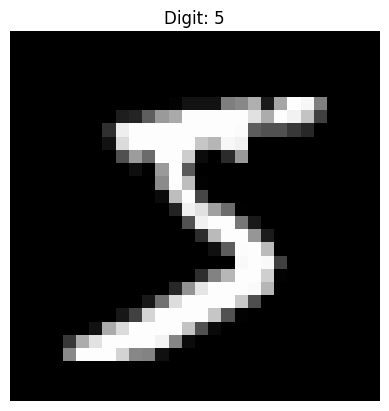

In [4]:
plt.imshow(X_train[0], cmap="gray")
plt.title(f"Digit: {y_train[0]}")
plt.axis("off")
plt.show()

In [5]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [7]:
from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import Flatten, Dense

model = Sequential([
    Input(shape=(28, 28)),
    Flatten(),
    Dense(128, activation="relu"),
    Dense(64, activation="relu"),
    Dense(10, activation="softmax")
])

In [8]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [9]:
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    validation_split=0.1
)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - accuracy: 0.9245 - loss: 0.2547 - val_accuracy: 0.9658 - val_loss: 0.1189
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - accuracy: 0.9662 - loss: 0.1094 - val_accuracy: 0.9748 - val_loss: 0.0868
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - accuracy: 0.9762 - loss: 0.0740 - val_accuracy: 0.9750 - val_loss: 0.0864
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - accuracy: 0.9818 - loss: 0.0572 - val_accuracy: 0.9745 - val_loss: 0.0851
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - accuracy: 0.9854 - loss: 0.0443 - val_accuracy: 0.9748 - val_loss: 0.0872


In [10]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9754 - loss: 0.0785
Test Accuracy: 0.9753999710083008


In [11]:
y_pred = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [12]:
y_pred_classes = np.argmax(y_pred, axis=1)

print("Predicted:", y_pred_classes[0])
print("Actual:", y_test[0])

Predicted: 7
Actual: 7


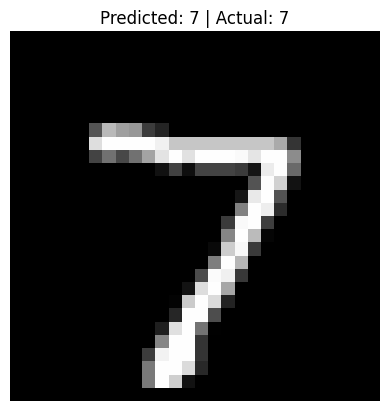

In [13]:
plt.imshow(X_test[0], cmap="gray")
plt.title(f"Predicted: {y_pred_classes[0]} | Actual: {y_test[0]}")
plt.axis("off")
plt.show()

In [14]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

In [15]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [16]:
cm = confusion_matrix(y_test, y_pred_classes)

print(cm)

[[ 961    1    1    1    1    2    5    3    3    2]
 [   0 1108    1    1    0    1    4    3   17    0]
 [   1    2  990    5    3    3    2   16    9    1]
 [   0    0    6  984    0    8    0    2    6    4]
 [   0    0    0    0  959    1    4    5    1   12]
 [   2    0    0    5    1  875    4    0    2    3]
 [   2    2    1    0    9   17  926    0    1    0]
 [   1    1    4    0    0    0    0 1017    2    3]
 [   0    0    3    2    3    7    0    3  953    3]
 [   0    2    0    3    4    5    0    6    8  981]]


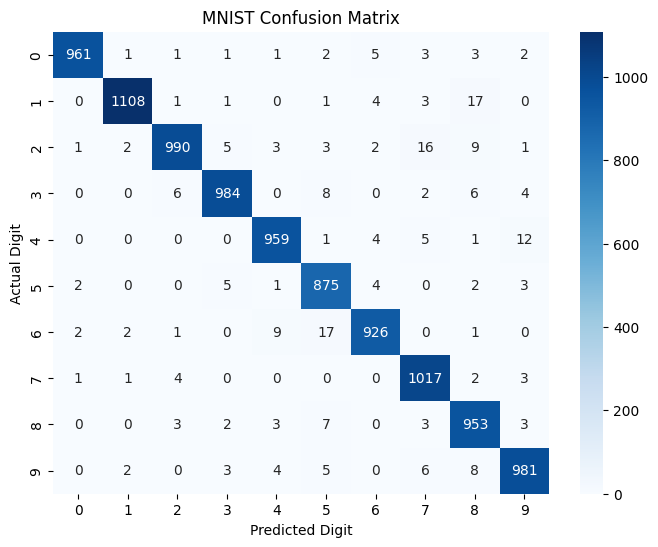

In [17]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted Digit")
plt.ylabel("Actual Digit")
plt.title("MNIST Confusion Matrix")
plt.show()

In [18]:
print(classification_report(y_test, y_pred_classes))

              precision    recall  f1-score   support

           0       0.99      0.98      0.99       980
           1       0.99      0.98      0.98      1135
           2       0.98      0.96      0.97      1032
           3       0.98      0.97      0.98      1010
           4       0.98      0.98      0.98       982
           5       0.95      0.98      0.97       892
           6       0.98      0.97      0.97       958
           7       0.96      0.99      0.98      1028
           8       0.95      0.98      0.96       974
           9       0.97      0.97      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



In [19]:
model.save("mnist_digit_model.keras")

In [20]:
import os

print(os.path.exists("mnist_digit_model.keras"))

True


In [21]:
from tensorflow.keras.models import load_model

saved_model = load_model("mnist_digit_model.keras")

In [22]:
saved_loss, saved_accuracy = saved_model.evaluate(X_test, y_test)

print("Saved Model Accuracy:", saved_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9754 - loss: 0.0785
Saved Model Accuracy: 0.9753999710083008


In [23]:
predictions = saved_model.predict(X_test)

predicted_digit = np.argmax(predictions[0])

print("Predicted Digit:", predicted_digit)
print("Actual Digit:", y_test[0])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Predicted Digit: 7
Actual Digit: 7


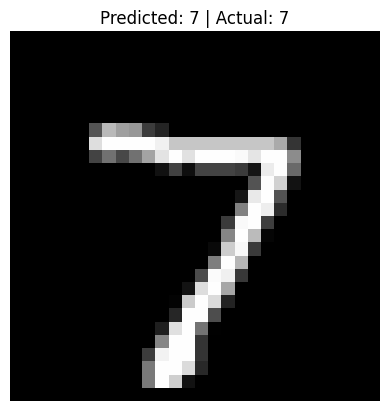

In [24]:
plt.imshow(X_test[0], cmap="gray")
plt.title(f"Predicted: {predicted_digit} | Actual: {y_test[0]}")
plt.axis("off")
plt.show()

In [25]:
X_train_knn = X_train.reshape(X_train.shape[0], -1)
X_test_knn = X_test.reshape(X_test.shape[0], -1)

print("Training shape:", X_train_knn.shape)
print("Testing shape:", X_test_knn.shape)

Training shape: (60000, 784)
Testing shape: (10000, 784)


In [26]:
X_train_knn_small = X_train_knn[:10000]
y_train_knn_small = y_train[:10000]

print("KNN Training shape:", X_train_knn_small.shape)

KNN Training shape: (10000, 784)


In [27]:
from sklearn.neighbors import KNeighborsClassifier

In [28]:
knn = KNeighborsClassifier(n_neighbors=3)

In [29]:
knn.fit(X_train_knn_small, y_train_knn_small)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[uint8](10,)","[0,1,2,...,7,8,9]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [30]:
knn_predictions = knn.predict(X_test_knn)

print("First 10 predictions:", knn_predictions[:10])
print("Actual values:", y_test[:10])

First 10 predictions: [7 2 1 0 4 1 4 9 5 9]
Actual values: [7 2 1 0 4 1 4 9 5 9]


In [31]:
from sklearn.metrics import accuracy_score

knn_accuracy = accuracy_score(y_test, knn_predictions)

print("KNN Accuracy:", knn_accuracy)

KNN Accuracy: 0.9463


In [32]:
print("Model Comparison")
print("-------------------------")
print(f"KNN Accuracy: {knn_accuracy:.4f}")
print(f"Neural Network Accuracy: {test_accuracy:.4f}")
print(f"Improvement: {(test_accuracy - knn_accuracy) * 100:.2f}%")

Model Comparison
-------------------------
KNN Accuracy: 0.9463
Neural Network Accuracy: 0.9754
Improvement: 2.91%
